# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 14:24:44.093755: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python executable: /Users/leoxie/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32) - 1
    X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt"),  dtype=np.float32)
    y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt"),  dtype=np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)
print("num_features :", num_features)
print("num_classes  :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test  shape: (2947, 561)
y_test  shape: (2947,)
num_features : 561
num_classes  : 6


## 4. Quick Inspection

In [4]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

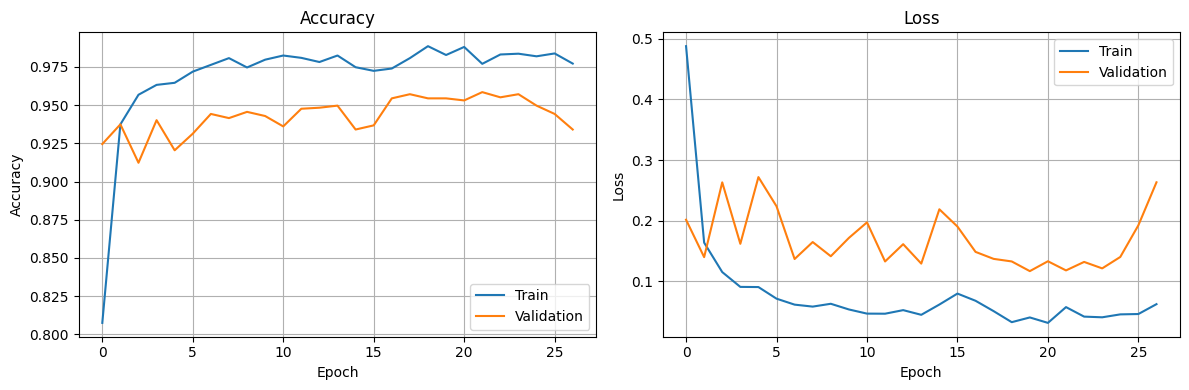

In [7]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="Train")
axes[0].plot(history_df["val_accuracy"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_df["loss"], label="Train")
axes[1].plot(history_df["val_loss"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

Baseline Keras Test Accuracy: 0.9362

                    precision    recall  f1-score   support

           WALKING     0.9108    0.9879    0.9478       496
  WALKING_UPSTAIRS     0.9477    0.8854    0.9155       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8639    0.9662    0.9122       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9362      2947
         macro avg     0.9397    0.9349    0.9359      2947
      weighted avg     0.9391    0.9362    0.9362      2947



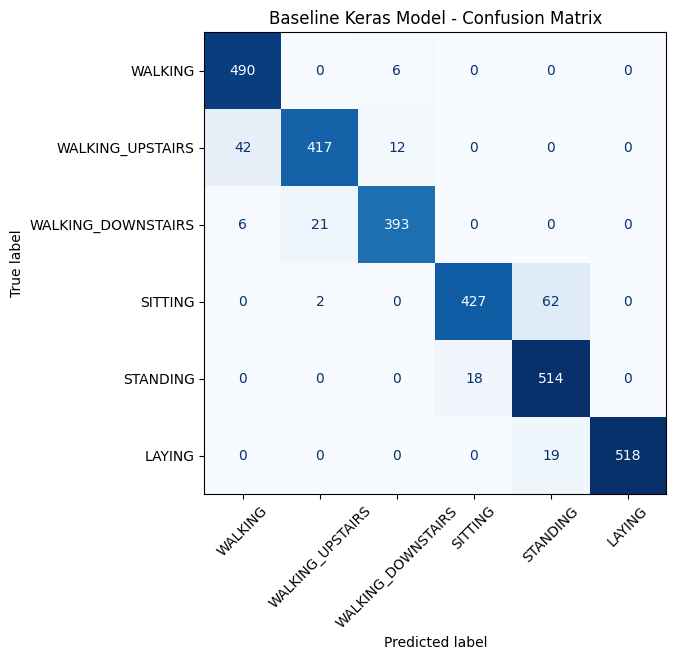

In [8]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, baseline_fp32_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite Accuracy: {baseline_fp32_acc:.4f}")
print(f"Baseline FP32 TFLite Size (KB): {baseline_fp32_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp96yas685/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp96yas685/assets


Baseline FP32 TFLite Accuracy: 0.9362
Baseline FP32 TFLite Size (KB): 726.72


2026-04-23 14:24:59.727505: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:24:59.727521: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:24:59.727840: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp96yas685
2026-04-23 14:24:59.728972: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:24:59.728984: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp96yas685
2026-04-23 14:24:59.731305: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 14:24:59.732168: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:24:59.773119: I tensorflow/cc/saved_model/loader.

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

base_for_pruning = build_baseline_model(num_features, num_classes)
base_for_pruning.set_weights(baseline_model.get_weights())

pruned_model = prune_low_magnitude(base_for_pruning, **pruning_params)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)


Epoch 1/12
92/92 [==============================] - 2s 5ms/step - loss: 0.0572 - accuracy: 0.9770 - val_loss: 0.1422 - val_accuracy: 0.9531
Epoch 2/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0392 - accuracy: 0.9862 - val_loss: 0.1373 - val_accuracy: 0.9531
Epoch 3/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0311 - accuracy: 0.9900 - val_loss: 0.1449 - val_accuracy: 0.9524
Epoch 4/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0320 - accuracy: 0.9893 - val_loss: 0.1362 - val_accuracy: 0.9551
Epoch 5/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0309 - accuracy: 0.9881 - val_loss: 0.1484 - val_accuracy: 0.9551
Epoch 6/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0516 - accuracy: 0.9828 - val_loss: 0.1740 - val_accuracy: 0.9456
Epoch 7/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1250 - accuracy: 0.9604 - val_loss: 0.1196 - val_accuracy: 0.9545


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# (1) Pruned model, wrappers still attached -> FP32 TFLite
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# (2) Strip the pruning wrappers, then convert with sparsity-aware optimization
stripped_pruned_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned (with mask) FP32  acc={pruned_with_mask_acc:.4f}  size={pruned_with_mask_size_kb:.2f} KB")
print(f"Stripped Sparse     FP32  acc={stripped_sparse_acc:.4f}  size={stripped_sparse_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyv37an1p/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyv37an1p/assets
2026-04-23 14:25:06.655407: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:25:06.655424: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:25:06.655607: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyv37an1p
2026-04-23 14:25:06.659356: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:25:06.659369: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyv37an1p
2026-04-23 14:25:06.669916: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:25:06.729205: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyy97q2ag/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyy97q2ag/assets
2026-04-23 14:25:07.815735: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:25:07.815752: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:25:07.815910: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyy97q2ag
2026-04-23 14:25:07.816558: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:25:07.816567: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpyy97q2ag
2026-04-23 14:25:07.818179: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:25:07.835740: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned (with mask) FP32  acc=0.9352  size=1454.18 KB
Stripped Sparse     FP32  acc=0.9352  size=424.94 KB


## 11. Part I Comparison: Accuracy and Model Size

In [13]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_results = pd.DataFrame([
    ["Baseline TFLite",        "FP32",          baseline_fp32_acc,     baseline_fp32_size_kb],
    ["Pruned TFLite (w/mask)", "FP32",          pruned_with_mask_acc,  pruned_with_mask_size_kb],
    ["Stripped Sparse TFLite", "FP32 + Sparse", stripped_sparse_acc,   stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part1_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline TFLite,FP32,0.936206,726.718750
1,Pruned TFLite (w/mask),FP32,0.935188,1454.175781
2,Stripped Sparse TFLite,FP32 + Sparse,0.935188,424.937500


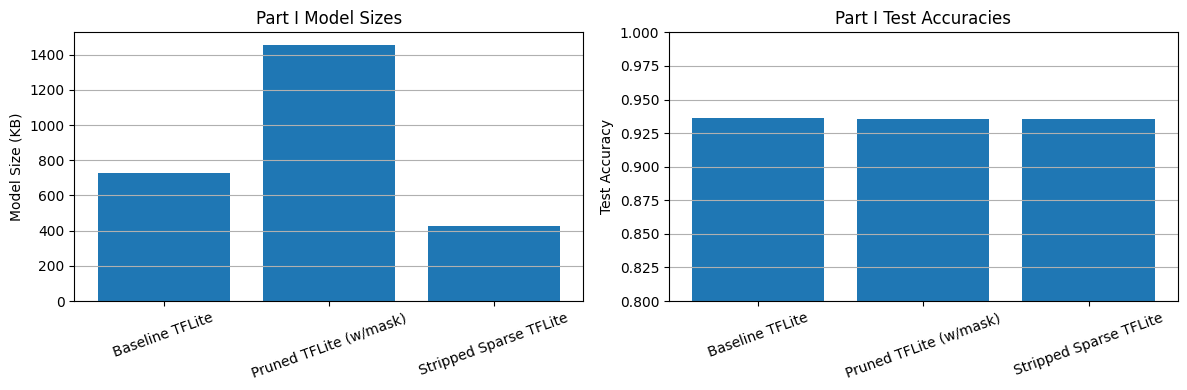

In [14]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(part1_results["Model"], part1_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I Model Sizes")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y")

axes[1].bar(part1_results["Model"], part1_results["Test Accuracy"])
axes[1].set_ylim(0.80, 1.00)
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part I Test Accuracies")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

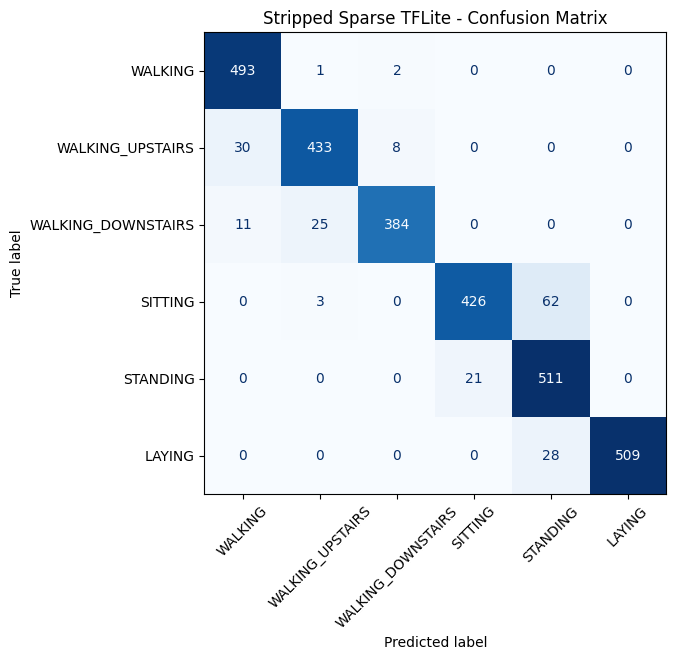

                    precision    recall  f1-score   support

           WALKING     0.9232    0.9940    0.9573       496
  WALKING_UPSTAIRS     0.9372    0.9193    0.9282       471
WALKING_DOWNSTAIRS     0.9746    0.9143    0.9435       420
           SITTING     0.9530    0.8676    0.9083       491
          STANDING     0.8502    0.9605    0.9020       532
            LAYING     1.0000    0.9479    0.9732       537

          accuracy                         0.9352      2947
         macro avg     0.9397    0.9339    0.9354      2947
      weighted avg     0.9386    0.9352    0.9354      2947



In [15]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse TFLite - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [16]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# (1) Pruned model with mask -> float16 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_with_mask_fp16_tflite = converter.convert()
pruned_with_mask_fp16_size_kb = save_binary_model(pruned_with_mask_fp16_tflite, "pruned_with_mask_fp16.tflite")
pruned_with_mask_fp16_acc, pruned_with_mask_fp16_preds = evaluate_tflite_model(pruned_with_mask_fp16_tflite, X_test, y_test)

# (2) Stripped sparse model -> float16 TFLite with sparsity-aware optimization
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_fp16_tflite = converter.convert()
stripped_sparse_fp16_size_kb = save_binary_model(stripped_sparse_fp16_tflite, "stripped_sparse_fp16.tflite")
stripped_sparse_fp16_acc, stripped_sparse_fp16_preds = evaluate_tflite_model(stripped_sparse_fp16_tflite, X_test, y_test)

print(f"Pruned (w/mask) FP16         acc={pruned_with_mask_fp16_acc:.4f}  size={pruned_with_mask_fp16_size_kb:.2f} KB")
print(f"Stripped Sparse FP16         acc={stripped_sparse_fp16_acc:.4f}  size={stripped_sparse_fp16_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp0jv6u_wm/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp0jv6u_wm/assets
2026-04-23 14:25:10.821487: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:25:10.821505: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:25:10.821709: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp0jv6u_wm
2026-04-23 14:25:10.825029: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:25:10.825047: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp0jv6u_wm
2026-04-23 14:25:10.835567: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:25:10.897358: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8no_a3ps/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8no_a3ps/assets
2026-04-23 14:25:12.070150: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:25:12.070165: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned (w/mask) FP16         acc=0.9352  size=732.59 KB
Stripped Sparse FP16         acc=0.9352  size=279.99 KB


2026-04-23 14:25:12.070316: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8no_a3ps
2026-04-23 14:25:12.070988: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:25:12.070997: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8no_a3ps
2026-04-23 14:25:12.072495: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:25:12.088842: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp8no_a3ps
2026-04-23 14:25:12.095999: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 25683 microseconds.


## 12. Part II Comparison: Accuracy and Model Size

In [17]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

part2_results = pd.DataFrame([
    ["Pruned TFLite (w/mask)",  "FP32",             pruned_with_mask_acc,       pruned_with_mask_size_kb],
    ["Stripped Sparse TFLite",  "FP32 + Sparse",    stripped_sparse_acc,        stripped_sparse_size_kb],
    ["Pruned TFLite (w/mask)",  "Float16",          pruned_with_mask_fp16_acc,  pruned_with_mask_fp16_size_kb],
    ["Stripped Sparse TFLite",  "Float16 + Sparse", stripped_sparse_fp16_acc,   stripped_sparse_fp16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned TFLite (w/mask),FP32,0.935188,1454.175781
1,Stripped Sparse TFLite,FP32 + Sparse,0.935188,424.937500
2,Pruned TFLite (w/mask),Float16,0.935188,732.585938
3,Stripped Sparse TFLite,Float16 + Sparse,0.935188,279.992188


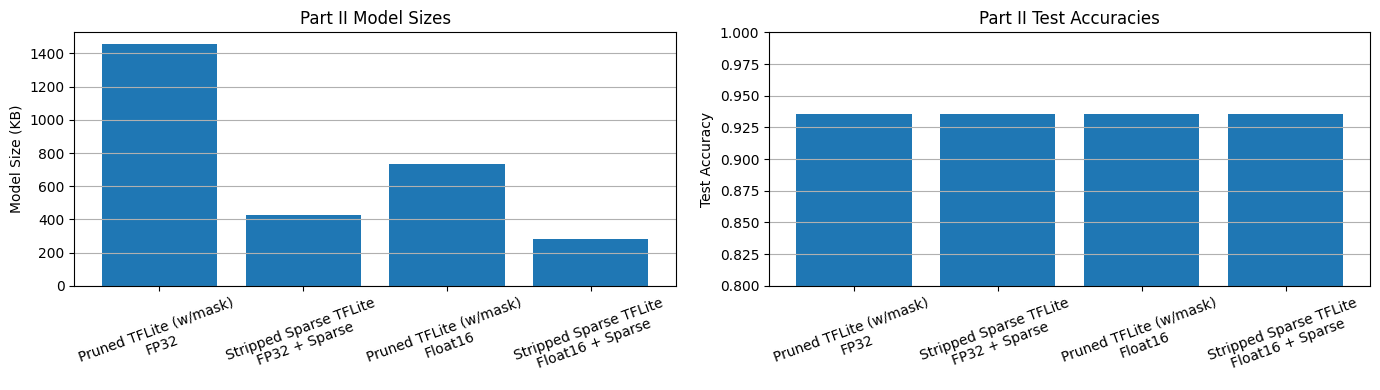

In [18]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

labels = part2_results["Model"] + "\n" + part2_results["Format"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(labels, part2_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II Model Sizes")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y")

axes[1].bar(labels, part2_results["Test Accuracy"])
axes[1].set_ylim(0.80, 1.00)
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part II Test Accuracies")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

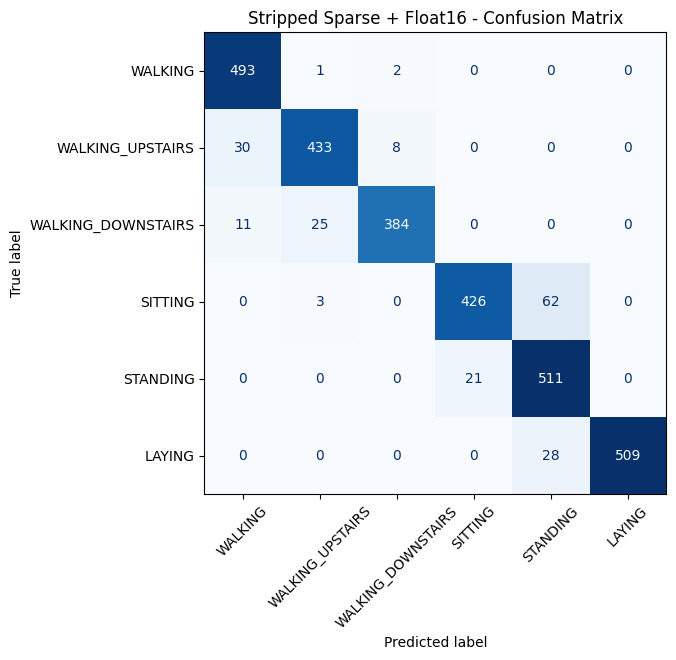

                    precision    recall  f1-score   support

           WALKING     0.9232    0.9940    0.9573       496
  WALKING_UPSTAIRS     0.9372    0.9193    0.9282       471
WALKING_DOWNSTAIRS     0.9746    0.9143    0.9435       420
           SITTING     0.9530    0.8676    0.9083       491
          STANDING     0.8502    0.9605    0.9020       532
            LAYING     1.0000    0.9479    0.9732       537

          accuracy                         0.9352      2947
         macro avg     0.9397    0.9339    0.9354      2947
      weighted avg     0.9386    0.9352    0.9354      2947



In [19]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_fp16_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse + Float16 - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_fp16_preds, target_names=class_names, digits=4))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached? 

**No, it doesn't reduce file size on disk until you strip it.**

2. Why does `strip_pruning(...)` matter before export? 

**strip prunning is that actually turn prunning into disk savings.**

3. Which model had the smallest file size in this notebook? 

**stripped sparse float16 has the smallest file size in this notebook at 279.99 kB.**

4. Did float16 quantization noticeably change the test accuracy? 

**No, the accuracy wasn't dramatically affected by the float16 quantization.**

5. If you were deploying this model on a resource-constrained device, which version would you choose and why? 

**I would deploy the float 16 quantization model, because it has small size and a good performance retention rate.**


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
